In [1]:
%config Completer.use_jedi = False

In [2]:
import warnings
warnings.filterwarnings('ignore')

### 비지도 학습
- Target이 없는 데이터 분류하기
- 군집화와 차원축소가 있음

---
### 군집 알고리즘
: 과일 데이터 사진을 보고 사과, 파인애플, 바나나로 3분류 하기

In [3]:
# 과일 데이터 불러오기
import numpy as np

In [4]:
fruits = np.load("/kaggle/input/data-fruits/fruits.npy")
fruits.shape

(300, 100, 100)

> 흑백 이미지   
> 300개의 이미지가 100X100픽셀로 구성되어 있음.   
> 100개는 사과, 100개는 파인애플, 100개는 바나나로 구성   

In [5]:
fruits[0,0,:]

array([  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   4,   3,   2,   1,   0,   0,   0,
         0,   6,   1,   0,   4,   3,   0,   1,   8,  14,   0,   0,   4,
         8,  13,  13, 156, 191, 116,  30,   3,   0,   0,   3,   6,   2,
         1,   0,   0,   0,   0,   1,   4,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1], dtype=int32)

> 1장의 흑백 이미지중 1번행만 출력한 것이다.    
> 최대 숫자가 255이며 255는 흰색이고 0으로 근접할 수록 흑색이다.  

In [6]:
# 사과 이미지 보기 : 이미지로 확인하기 
import matplotlib.pyplot as plt

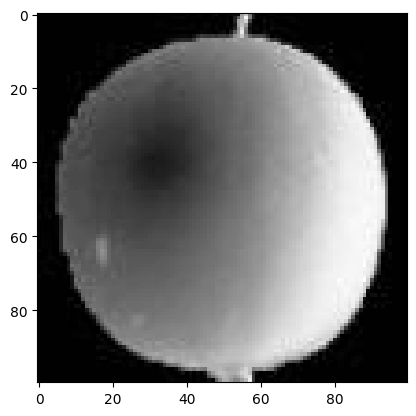

In [7]:
plt.imshow(fruits[0], cmap='gray')
plt.show()

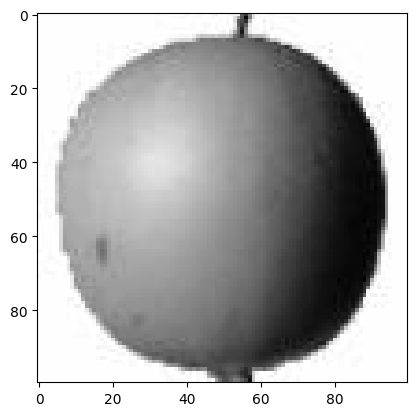

In [8]:
# 보기 편하게 변경하기
plt.imshow(fruits[0], cmap='gray_r')
plt.show()

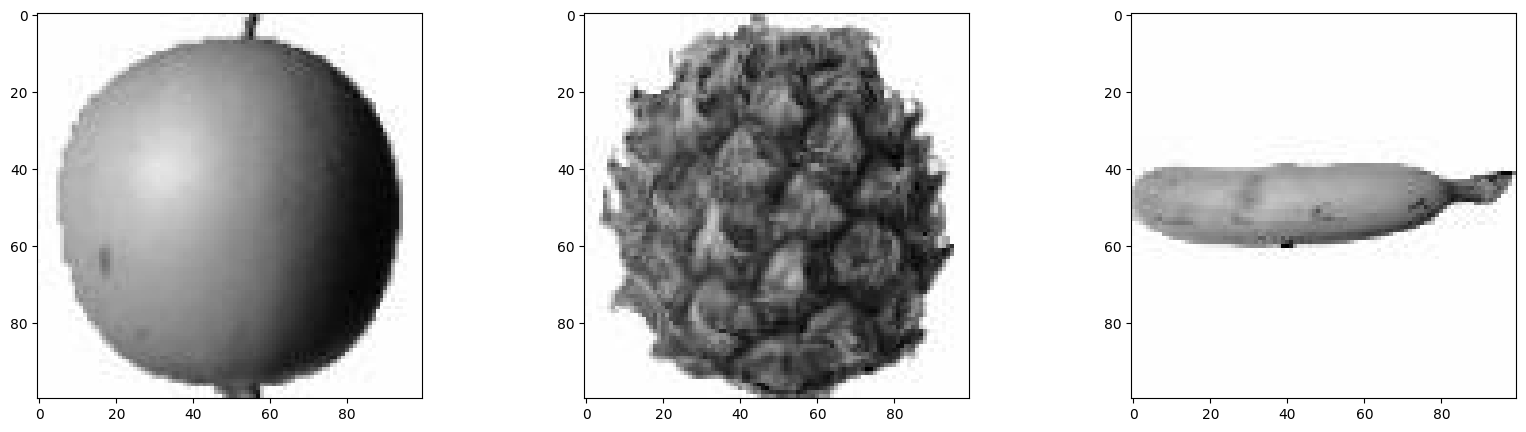

In [9]:
# 사과, 파인애플, 바나나 이미지를 나란히 보기
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].imshow(fruits[0], cmap='gray_r')
axs[1].imshow(fruits[100], cmap='gray_r')
axs[2].imshow(fruits[200], cmap='gray_r')
plt.show()

### 샘플 차원 변경하기
- 현재 3차원의 배열을 분석하기 위해 2차원 배열로 변경 하기
- 배열중 page단의 변수는 apple,pineapple,banana로 분류하여 변경하기

In [10]:
apple = fruits[0:100].reshape(-1, 100*100)
pineapple = fruits[100:200].reshape(-1, 100*100)
banana = fruits[200:300].reshape(-1, 100*100)

In [11]:
apple.shape

(100, 10000)

### 픽셀값 분석하기 

In [12]:
# apple의 sample별(행별) 평균 구하기
apple.mean(axis=1)

array([ 88.4588,  98.0594,  87.4831,  98.4898,  92.9991,  82.7579,
        94.536 ,  95.7095,  90.7508,  81.7788,  87.1803,  95.2125,
        93.9517,  87.1466,  97.6411,  87.3593,  89.0571, 101.0366,
        92.8971, 101.0462, 105.0824,  88.7961,  99.6585,  97.359 ,
        94.2293,  92.2932,  95.2592,  93.4393, 103.0312,  94.7767,
        90.6388,  89.1673,  97.8923,  97.4053, 100.8732,  90.6799,
       100.3753,  85.9834,  96.5866,  97.2989,  90.8155, 102.4502,
        87.3238,  89.9929,  86.8717,  86.4904,  95.3862,  89.289 ,
        96.9175,  91.782 ,  96.2412,  99.7925,  95.1062,  87.5648,
        89.3416,  89.6668,  93.9096,  97.5639,  87.2779,  97.9526,
       103.3378,  94.5728,  83.8009,  83.6077, 102.9481,  87.1496,
        91.3842, 100.5921,  93.9603,  90.9806,  97.5707,  97.574 ,
        82.5605,  87.2897,  97.0628,  90.4258,  90.6506,  97.741 ,
        98.1869,  93.7264,  87.536 ,  84.8565,  89.2303,  86.8919,
        88.8434,  86.7783,  96.8703,  97.3682,  82.0917,  87.3

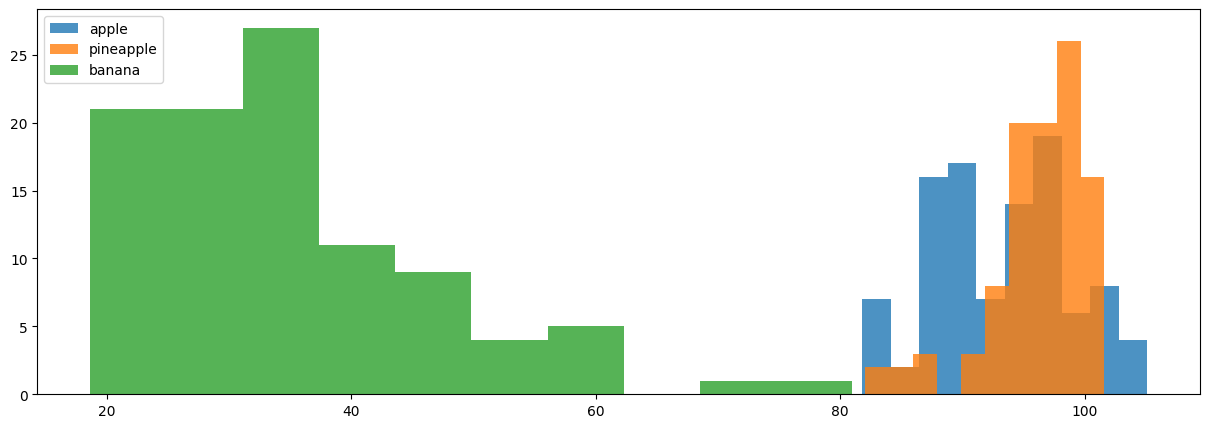

In [13]:
# 과일별(sample별) 빈도수를 히스토그램 표현
plt.figure(figsize=(15,5))
plt.hist(np.mean(apple, axis=1), alpha=0.8)
plt.hist(np.mean(pineapple, axis=1), alpha=0.8)
plt.hist(np.mean(banana, axis=1), alpha=0.8)
plt.legend(['apple', 'pineapple', 'banana'])

plt.show()

> x축은 픽셀의 평균값, y축은 빈도수    
> 바나나와 다른 과일은 분리가 쉬우나 사과와 파인애플은 분리가 어렵다.    
> 바나나의 크기는 작고 사과와 파인애플의 그림 크기는 비슷하다.   

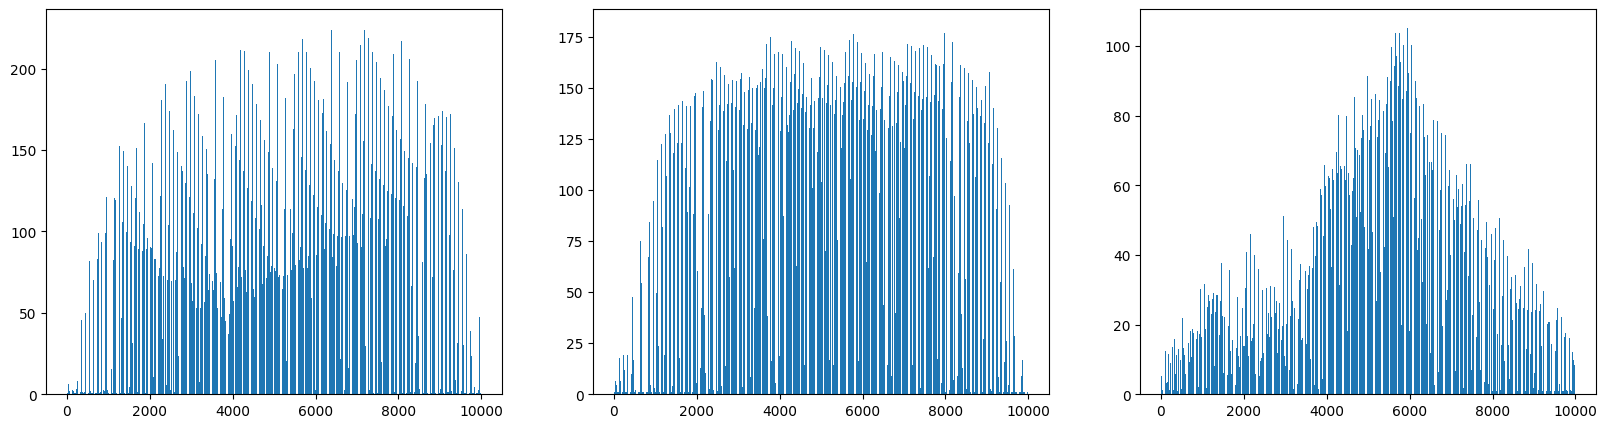

In [14]:
# Feature별(픽셀별) 평균의 막대 그래프 그리기 
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].bar(
    range(100*100),
    np.mean(apple, axis=0)
)

axs[1].bar(
    range(100*100),
    np.mean(pineapple, axis=0)
)

axs[2].bar(
    range(100*100),
    np.mean(banana, axis=0)
)

plt.show()

> x축은 픽셀갯수 10000개, y축은 평균값   
> 바나나인 경우에는 중앙값이 높다.   
> 사과는 이미지의 아랫쪽 부분이 높다.   
> 파인애플은 전반적으로 고르게 분포하고 있다.

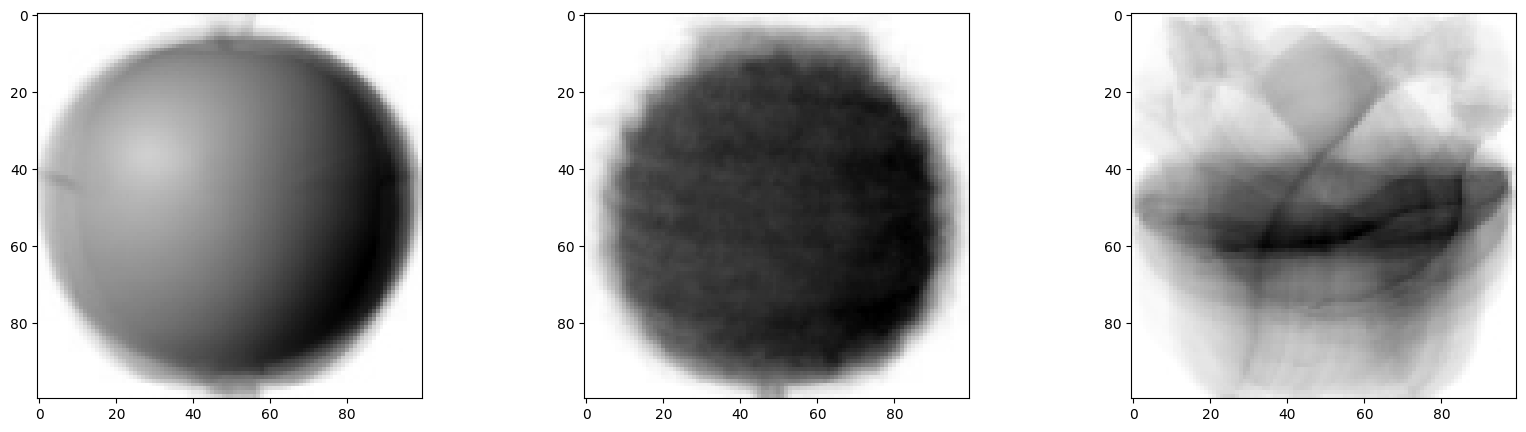

In [15]:
# 평균 이미지로 그림 표현하기 : 이미지로 그리기 위해 다시 2차원배열로 변경

apple_mean = np.mean(apple, axis=0).reshape(100, 100)
pineapple_mean = np.mean(pineapple, axis=0).reshape(100, 100)
banana_mean = np.mean(banana, axis=0).reshape(100, 100)

fig, axs = plt.subplots(1,3, figsize=(20,5))
axs[0].imshow(apple_mean, cmap='gray_r')
axs[1].imshow(pineapple_mean, cmap='gray_r')
axs[2].imshow(banana_mean, cmap='gray_r')

plt.show()

> 각 과일의 픽셀별 평균을 이미지로 그린 그림이다

### 평균과 가까운 사진 고르기
- 위에서 구한 평균 이미지와 각 샘플들의 픽셀값과 비교하여 가까운 거리의 이미지는 해당 과일일 것이다.
- 사과만 잘 분류하는지 시도

In [16]:
# 양수와 음수의 구분이 필요없는 거리측정
abs_diff = np.abs(fruits - apple_mean)

# abs_diff가 3차원이기 때문에 page차원을 제외하고 행과 열만의 평균을 구한다.
abs_mean = np.mean(abs_diff, axis=(1,2)) 

abs_mean.shape

(300,)

In [17]:
abs_mean

array([17.357734, 13.554336, 17.202008, 15.769808, 18.019082, 20.55447 ,
       16.803214, 16.124154, 19.59156 , 21.365726, 16.465608, 16.603126,
       13.41592 , 17.248916, 15.977246, 15.477304, 18.571426, 16.52309 ,
       27.595128, 19.7579  , 20.823426, 16.460124, 17.103872, 15.88027 ,
       15.058592, 19.361638, 24.031656, 14.786244, 19.27237 , 20.824594,
       14.814994, 18.677796, 15.906604, 13.10645 , 18.453898, 16.616742,
       16.327252, 18.969418, 13.913228, 16.51597 , 18.388472, 19.183942,
       29.117914, 18.440636, 28.192728, 21.463068, 19.732278, 15.57259 ,
       13.11697 , 18.756192, 14.416062, 21.528646, 26.231478, 15.918032,
       18.57341 , 16.42997 , 17.080708, 13.190102, 18.24878 , 13.520802,
       20.85775 , 16.882222, 22.814864, 19.030818, 19.13427 , 16.628244,
       14.860376, 19.391788, 14.828492, 14.48473 , 13.119974, 15.92342 ,
       20.417536, 16.248422, 13.734026, 18.429454, 15.216936, 16.411588,
       13.49728 , 20.012288, 17.256706, 21.156152, 

In [18]:
# 300개의 데이터중 차이가 적은순으로 정렬하면 이미지 불러오기
apple_index = np.argsort(abs_mean)[:100]
apple_index

array([33, 48, 70, 57, 87, 12, 78, 59,  1, 74, 86, 38, 50, 92, 69, 27, 30,
       68, 66, 24, 76, 15, 98, 84, 47, 90,  3, 94, 23, 32, 53, 71, 14,  7,
       73, 36, 77, 55, 21, 10, 39, 17, 99, 11, 35, 65, 95,  6, 61, 56, 22,
       89,  2, 13, 80,  0, 97,  4, 58, 40, 75, 43, 34, 82, 16, 54, 31, 49,
       93, 37, 63, 64, 41, 28, 25, 96, 67,  8, 83, 46, 19, 79, 72,  5, 85,
       20, 29, 60, 81,  9, 45, 51, 88, 62, 91, 26, 52, 18, 44, 42])

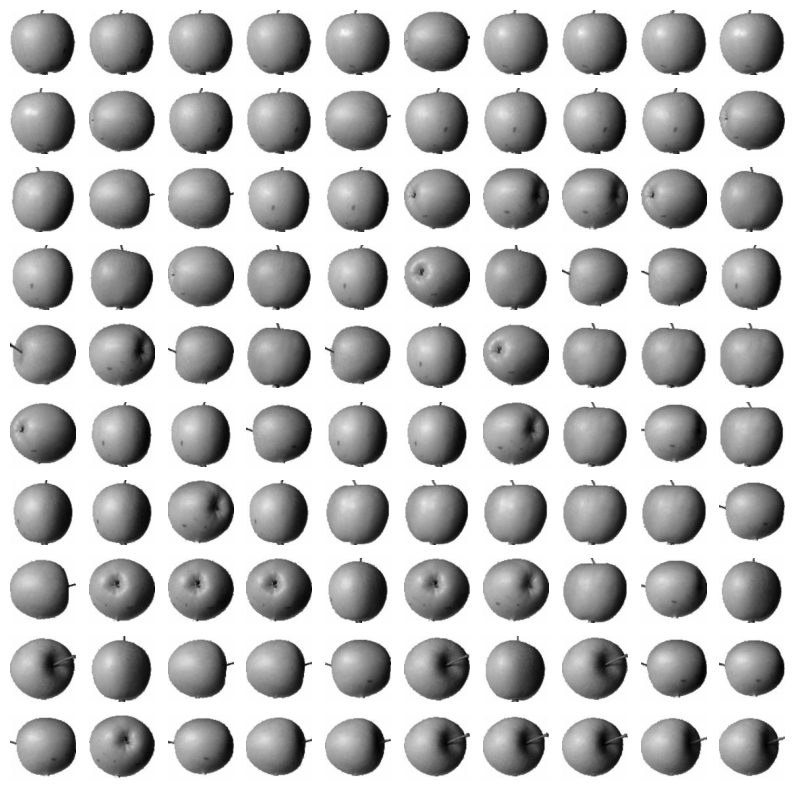

In [19]:
# 그림 그려보기
fig, axs = plt.subplots(10, 10, figsize=(10, 10))

for i in range(10):
    for j in range(10):
        axs[i,j].imshow(fruits[apple_index[i*10+j]], cmap='gray_r')
        axs[i,j].axis('off')

plt.show()

> 이와 같은 방법으로 비지도 학습인 군집분류의 알고리즘이 구성되어 있다. 

---
### 바나나로 확인해 보기

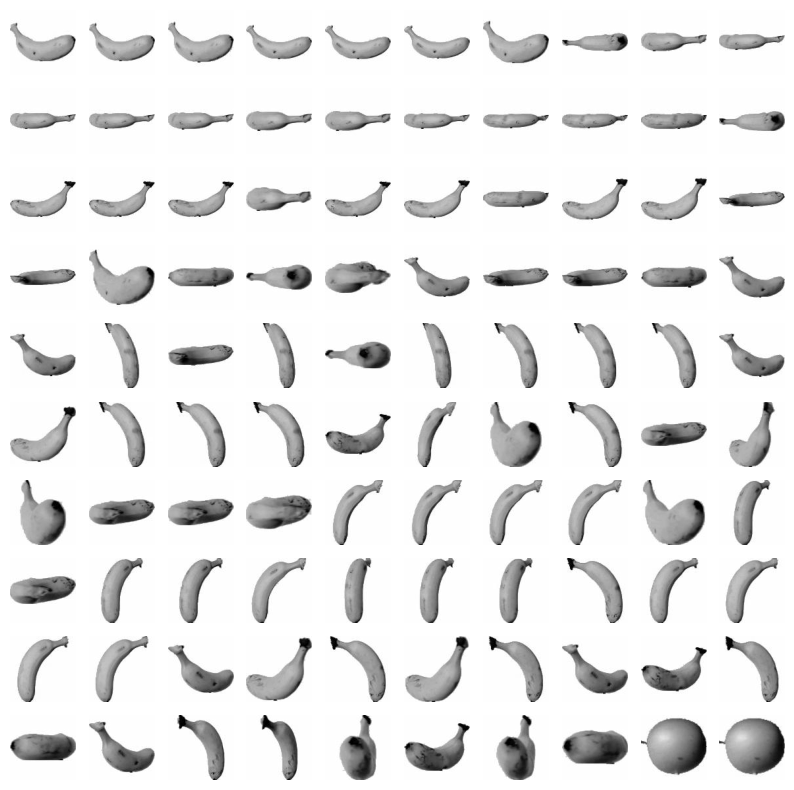

In [20]:
abs_diff = np.abs(fruits - banana_mean)
abs_mean = np.mean(abs_diff, axis=(1,2)) 
banana_index = np.argsort(abs_mean)[:100]

fig, axs = plt.subplots(10, 10, figsize=(10, 10))

for i in range(10):
    for j in range(10):
        axs[i,j].imshow(fruits[banana_index[i*10+j]], cmap='gray_r')
        axs[i,j].axis('off')

plt.show()